Setup dan Fungsi Utama

In [1]:
import pandas as pd
import re
import os
from google_play_scraper import Sort, reviews

print("Setup library dan fungsi berhasil!")

# Daftar Aplikasi
apps = [
    {"name": "Shopee",    "id": "com.shopee.id"},
    {"name": "Tokopedia", "id": "com.tokopedia.tkpd"},
    {"name": "Gojek",     "id": "com.gojek.app"},
    {"name": "OVO",       "id": "ovo.id"},
    {"name": "DANA",      "id": "id.dana"},
    {"name": "TikTok",    "id": "com.zhiliaoapp.musically"},
]

# Keyword Emosi
emotion_keywords = {
    "marah": ["kesel", "benci", "nyebelin", "menyebalkan", "bikin emosi", "marah", "emosi", "geram", "jengkel", "kesal", "parah banget", "ngeselin", "kurang ajar", "brengsek", "rese", "goblok", "tolol", "ancur", "sampah", "tidak profesional", "payah", "kecewa banget", "mengecewakan", "bikin kesel", "ga beres", "amburadul"],
    "senang": ["senang", "seneng", "bahagia", "happy", "puas", "mantap", "bagus banget", "keren", "luar biasa", "terbaik", "recommended", "suka banget", "memuaskan", "terima kasih", "makasih", "alhamdulillah", "syukur", "bersyukur", "sempurna", "top banget", "sangat membantu", "helpful", "akhirnya", "berhasil", "sukses", "worked"],
    "sedih": ["sedih", "kecewa", "失望", "nangis", "nangis banget", "patah hati", "menyedihkan", "kehilangan", "sakit hati", "down", "galau", "nelangsa", "kasihan", "mengenaskan", "mengharukan", "terharu", "menyesal", "nyesel", "rugi", "gagal", "tidak berhasil", "zonk", "hampa"],
    "stres": ["stres", "stress", "pusing", "ribet", "susah banget", "error terus", "bug", "crash", "lemot", "lelet", "loading lama", "ga bisa masuk", "tidak bisa login", "stuck", "lag", "not responding", "force close", "bingung", "muter-muter", "capek", "lelah", "repot", "susah dipake", "membingungkan", "ruwet"],
    "netral": ["oke", "lumayan", "biasa aja", "standar", "cukup", "tidak ada masalah", "normal", "sesuai", "seperti biasa", "wajar", "biasa", "sama aja", "not bad", "so so", "bisa dipakai", "fungsional", "berjalan", "jalan", "tidak lebih tidak kurang", "seadanya"]
}

def label_emotion(text):
    text_lower = text.lower()
    scores = {label: 0 for label in emotion_keywords}
    for label, keywords in emotion_keywords.items():
        for kw in keywords:
            if kw in text_lower:
                scores[label] += 1
    if max(scores.values()) == 0:
        return None
    return max(scores, key=scores.get)

def clean_text_basic(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

Setup library dan fungsi berhasil!


Eksekusi Gathering Data (Scraping)

In [ ]:
print("Memulai proses scraping")

COUNT_PER_APP = 10000 
all_data = []

for app in apps:
    print(f"Scraping {app['name']}...")
    try:
        result, _ = reviews(
            app["id"], lang="id", country="id", sort=Sort.NEWEST, count=COUNT_PER_APP, filter_score_with=None
        )
        
        for r in result:
            text = clean_text_basic(r["content"])
            if len(text) < 10:
                continue
                
            label = label_emotion(text)
            if label is None:
                continue
                
            all_data.append({"text": text, "label": label, "app": app["name"], "date": r["at"]})
            
        print(f"✅ {app['name']} selesai!")
    except Exception as e:
        print(f"❌ ERROR {app['name']}: {e}")

print(f"\nTotal data terlabel terkumpul: {len(all_data)}")

Memulai proses scraping... (Ini mungkin memakan waktu agak lama)
Scraping Shopee...
✅ Shopee selesai!
Scraping Tokopedia...
✅ Tokopedia selesai!
Scraping Gojek...
✅ Gojek selesai!
Scraping OVO...
✅ OVO selesai!
Scraping DANA...
✅ DANA selesai!
Scraping TikTok...
✅ TikTok selesai!

Total data terlabel terkumpul: 18524


Assessing, Cleaning, & Feature Engineering

In [9]:
# Membuat DataFrame
df = pd.DataFrame(all_data)

# Hapus duplikat
df.drop_duplicates(subset=["text"], inplace=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Feature Engineering (Syarat Side Quest)
df['char_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Assessing Data (Syarat Main Quest)
print("=== ASSESSING DATA ===")
print("Missing Values:\n", df.isna().sum())
print("\nDistribusi Label (Belum Seimbang):\n", df["label"].value_counts())
print(f"\nTotal data bersih saat ini: {len(df)}")

=== ASSESSING DATA ===
Missing Values:
 text           0
label          0
app            0
date           0
char_length    0
word_count     0
dtype: int64

Distribusi Label (Belum Seimbang):
 label
senang    6195
stres     4385
sedih     2403
marah     1884
netral    1814
Name: count, dtype: int64

Total data bersih saat ini: 16681


Pertanyaan Bisnis yang Dapat diukur:

1. Analisis Kompetitor: Di antara 6 aplikasi (Shopee, Tokopedia, Gojek, OVO, DANA, TikTok), aplikasi mana yang memiliki rasio emosi negatif (stres, marah, sedih) paling tinggi dibandingkan emosi positif (senang)?
2. Analisis Perilaku Pengguna: Apakah ada hubungan antara panjang teks ulasan pengguna (word_count) dengan jenis emosi yang mereka rasakan? (Misalnya: apakah orang yang stres cenderung menulis ulasan lebih panjang daripada yang netral?)
3. Fokus Perbaikan: Berdasarkan distribusi emosi, masalah utama apa (stres/marah/sedih) yang harus diprioritaskan oleh tim Customer Service di masing-masing aplikasi?

Balancing & Export Data

In [10]:
import os

# Balancing Data (Undersampling)
min_count = df["label"].value_counts().min()
print(f"Menyamakan jumlah data menjadi {min_count} per label...")

# Cara modern dan aman untuk GroupBy Sampling (tanpa apply)
df_balanced = df.groupby("label").sample(n=min_count, random_state=42)

# Shuffle (Acak urutan) ulang dan reset index
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribusi Label Setelah Balancing:")
print(df_balanced["label"].value_counts())

# Export dengan nama persis sesuai yang kamu minta
jalur_simpan = os.path.abspath(os.path.join("data", "dataset_emosi_balanced.csv"))
df_balanced.to_csv(jalur_simpan, index=False)

print(f"\n✅ DATASET BERHASIL DISIMPAN DI:\n{jalur_simpan}")
display(df_balanced.head())

Menyamakan jumlah data menjadi 1814 per label...

Distribusi Label Setelah Balancing:
label
netral    1814
senang    1814
stres     1814
marah     1814
sedih     1814
Name: count, dtype: int64

✅ DATASET BERHASIL DISIMPAN DI:
d:\Dicoding\Project Plan - CC26-PSU351\Data_Science_EmpathAI\data\dataset_emosi_balanced.csv


,text,label,app,date,char_length,word_count
0,oke lah cuma di saya gak ada dana instan nya g...,netral,DANA,2026-05-18 16:08:03,88,18
1,PUAS👍👍👍👍👍👍👍,senang,Shopee,2026-05-16 11:40:10,11,1
2,"memilih pengantaran gofood biasa, di jam sebel...",netral,Gojek,2026-04-29 21:47:24,496,77
3,"kenpa bisa saldo gk ada masuk, teman sy transf...",senang,OVO,2026-02-23 06:43:22,162,27
4,bagus aplikasi shoppe nya setiap belanja pasti...,stres,Shopee,2026-05-17 14:30:43,145,22


EDA & Visualisasi

Menjalankan Exploratory Data Analysis (EDA)...


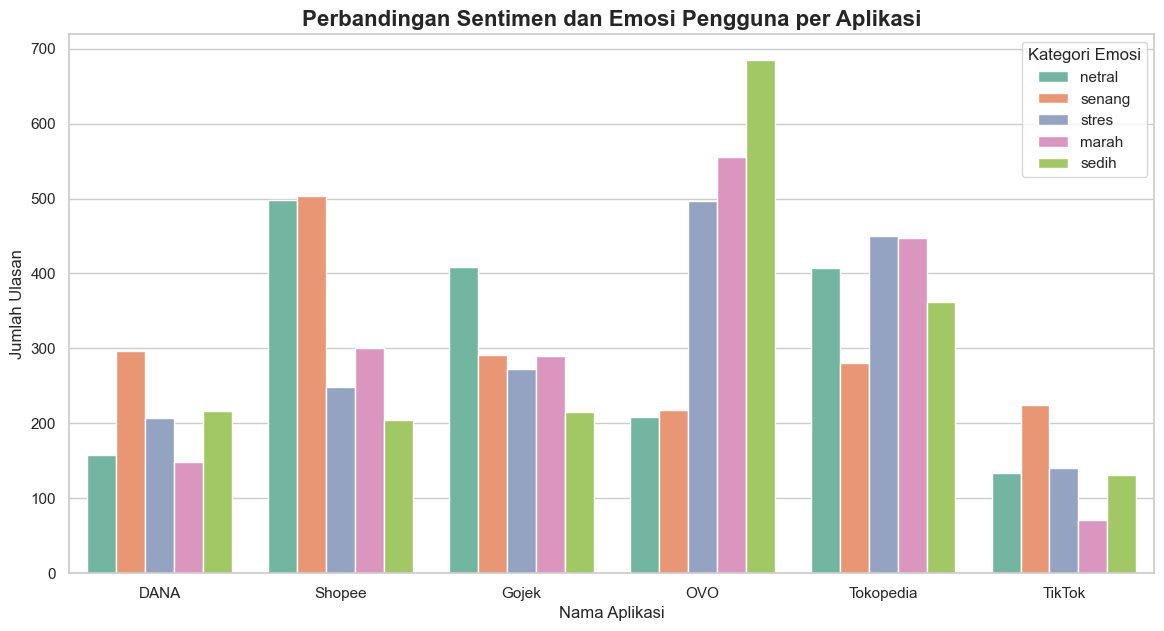

C:\Users\HP\AppData\Local\Temp\ipykernel_18316\2448888548.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_balanced, x='label', y='word_count', palette='pastel', showfliers=False)


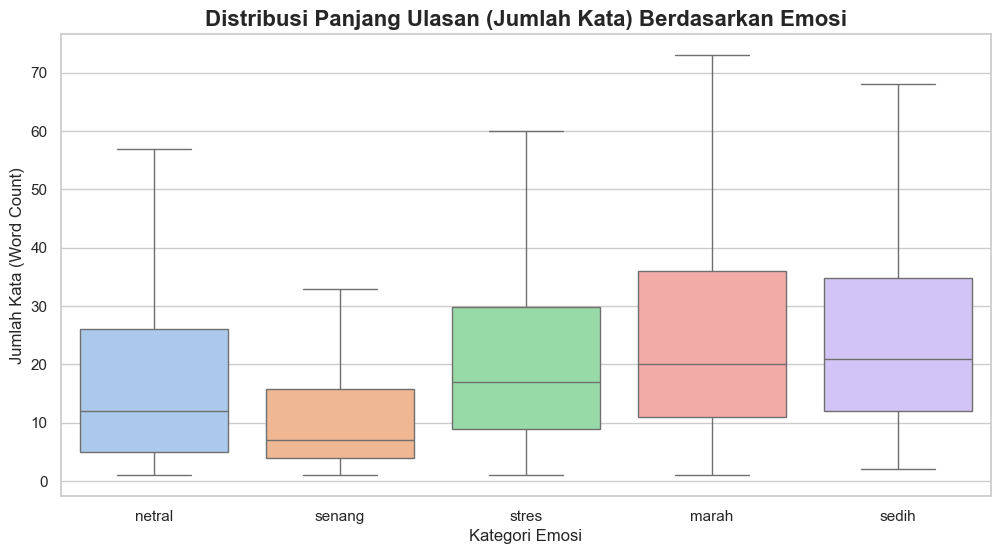

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setup visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Menjalankan Exploratory Data Analysis (EDA)...")

# 1. Visualisasi Distribusi Emosi per Aplikasi (Menjawab Pertanyaan 1 & 3)
plt.figure(figsize=(14, 7))
sns.countplot(data=df_balanced, x='app', hue='label', palette='Set2')
plt.title('Perbandingan Sentimen dan Emosi Pengguna per Aplikasi', fontsize=16, fontweight='bold')
plt.xlabel('Nama Aplikasi')
plt.ylabel('Jumlah Ulasan')
plt.legend(title='Kategori Emosi')
plt.show()

# 2. Visualisasi Hubungan Panjang Kata dengan Emosi (Menjawab Pertanyaan 2)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_balanced, x='label', y='word_count', palette='pastel', showfliers=False)
plt.title('Distribusi Panjang Ulasan (Jumlah Kata) Berdasarkan Emosi', fontsize=16, fontweight='bold')
plt.xlabel('Kategori Emosi')
plt.ylabel('Jumlah Kata (Word Count)')
plt.show()

A/B Testing

In [12]:
from scipy import stats

print("=== Hasil A/B Testing (T-Test) ===")
# Pisahkan populasi
marah_words = df_balanced[df_balanced['label'] == 'marah']['word_count']
senang_words = df_balanced[df_balanced['label'] == 'senang']['word_count']

# Lakukan T-Test (Asumsi varians berbeda / Welch's t-test)
t_stat, p_value = stats.ttest_ind(marah_words, senang_words, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Kesimpulan: Terdapat perbedaan yang signifikan secara statistik antara panjang ulasan pengguna yang marah dengan pengguna yang senang (Tolak H0).")
else:
    print("Kesimpulan: Tidak ada perbedaan yang signifikan secara statistik antara panjang ulasan pengguna yang marah dengan pengguna yang senang (Gagal Tolak H0).")

=== Hasil A/B Testing (T-Test) ===
T-Statistic: 22.7506
P-Value: 0.0000
Kesimpulan: Terdapat perbedaan yang signifikan secara statistik antara panjang ulasan pengguna yang marah dengan pengguna yang senang (Tolak H0).


Dashboard Streamlit

2026-05-30 21:17:13.240 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-30 21:17:13.242 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-30 21:17:14.093 
  command:

    streamlit run c:\Users\HP\miniforge3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-30 21:17:14.094 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-30 21:17:14.094 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-30 21:17:14.170 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-30 21:17:14.172 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runnin

DeltaGenerator()

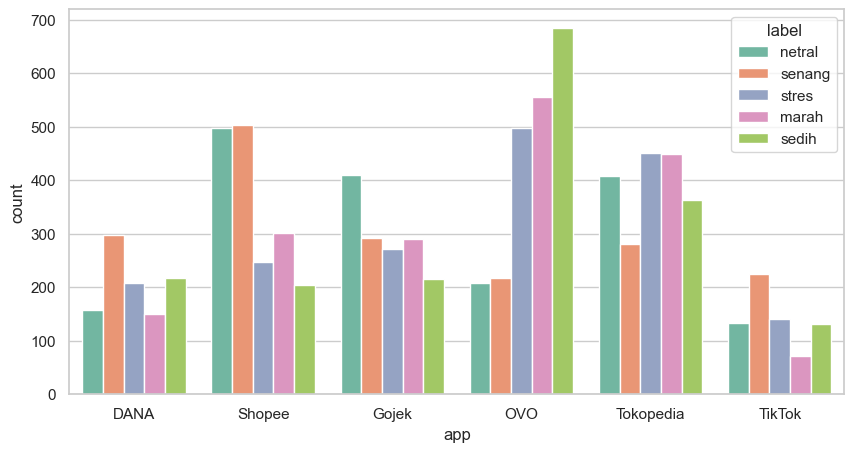

In [13]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="EmpathAI Dashboard", layout="wide")
st.title("Dashboard Analisis Emosi EmpathAI")

# Load data hasil pengolahan tadi
df = pd.read_csv("data/dataset_emosi_balanced.csv")

st.write("### Distribusi Emosi per Aplikasi")
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x='app', hue='label', palette='Set2', ax=ax)
st.pyplot(fig) # Menampilkan grafik di Streamlit

st.write("### Insight A/B Testing")
st.info("Berdasarkan uji statistik, pengguna yang mengekspresikan emosi negatif cenderung menulis ulasan lebih panjang dibandingkan emosi positif.")